In [ ]:
import pandas as pd
import numpy as np

tropomi_combined_dropna = pd.read_csv('/net/fs06/d3/rzhuang/TROPOMI_US/data/Run_500/updated_tropomi_hourly_emissions_full_variables.csv')
power_plants = pd.read_csv('/net/fs06/d3/rzhuang/TROPOMI_US/data/power_plants_with_combined_nearby_stats_parallel_debug.csv')

In [3]:
tropomi_combined_dropna.columns

Index(['location', 'facility_id', 'latitude', 'longitude', 'utc_time',
       'wind_u', 'wind_v', 'plume_label', 'file_path', 'State',
       'annual_nox_emission', 'surface_altitude', 'surface_altitude_precision',
       'surface_classification', 'surface_pressure', 'surface_albedo',
       'surface_albedo_nitrogendioxide_window', 'cloud_pressure_crb',
       'cloud_fraction_crb', 'cloud_albedo_crb', 'scene_albedo',
       'apparent_scene_pressure', 'snow_ice_flag', 'aerosol_index_354_388',
       'eastward_wind', 'northward_wind', 'scaled_small_pixel_variance',
       'tropospheric_NO2_column_number_density', 'sensor_altitude',
       'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle',
       'solar_zenith_angle', 'nearby_plants_count_20km', 'total_emission_20km',
       'percentage_emission_20km', 'nearby_plants_count_50km',
       'total_emission_50km', 'percentage_emission_50km',
       'nearby_plants_count_100km', 'total_emission_100km',
       'percentage_emiss

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report, cohen_kappa_score
import matplotlib.pyplot as pnotlt

# tropomi_combined_dropna['wind_speed'] = np.sqrt(tropomi_combined_dropna['wind_u']**2 + tropomi_combined_dropna['wind_v']**2)

# print(X)
X = tropomi_combined_dropna.iloc[:,10:]
# X = df.loc['surface_albedo']

y = tropomi_combined_dropna["plume_label"].astype(bool)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Balance training data
ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train, y_train)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression
model = LogisticRegression(max_iter=1000, random_state=42)
# model.fit(X_train_scaled, y_train_bal)
model.fit(X_train_scaled, y_train_bal)

# Evaluate model
y_pred = model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1]))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Kappa:", cohen_kappa_score(y_test, y_pred))


Accuracy: 0.7732658369124373
Precision: 0.25055843713322984
Recall: 0.6911027568922306
F1 Score: 0.36777904359665453
Confusion Matrix:
 [[70980 19795]
 [ 2958  6618]]
AUC: 0.8105494503724655
Classification Report:
               precision    recall  f1-score   support

       False       0.96      0.78      0.86     90775
        True       0.25      0.69      0.37      9576

    accuracy                           0.77    100351
   macro avg       0.61      0.74      0.61    100351
weighted avg       0.89      0.77      0.81    100351

Kappa: 0.26480082039537434


In [6]:
power_plants.sort_values('NOx Mass (short tons)')

,State,Facility Name,Facility ID,Gross Load (MWh),Steam Load (1000 lb),SO2 Mass (short tons),CO2 Mass (short tons),NOx Mass (short tons),Heat Input (mmBtu),Longitude,...,total_emission_100km,percentage_emission_100km,nearby_cities_count_20km,nearby_cities_pop_20km,nearby_cities_count_50km,nearby_cities_pop_50km,nearby_cities_count_100km,nearby_cities_pop_100km,nearby_cities_count_200km,nearby_cities_pop_200km
1341,KY,Phoenix Paper Wickliffe LLC,880065,0.00,0.0,0.000,0.000000e+00,0.000,0.000000e+00,-89.0792,...,1.006939e+08,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,2.0,283387.0
1340,PA,Shermans Dale Station,880050,0.00,0.0,0.000,0.000000e+00,0.000,0.000000e+00,-77.1628,...,1.166454e+08,0.000000,0.0,0.0,2.0,551930.0,7.0,1558160.0,36.0,11940071.0
1343,CA,Olive,6013,0.00,0.0,0.000,0.000000e+00,0.000,0.000000e+00,-118.3147,...,7.077293e+07,0.000000,5.0,12443139.0,42.0,16045267.0,82.0,24530422.0,105.0,30328945.0
1336,VT,Berlin 5,3734,0.00,0.0,0.000,9.180400e+03,0.000,1.133596e+05,-72.6035,...,2.913674e+06,0.315080,0.0,0.0,0.0,0.0,1.0,123307.0,18.0,5769888.0
1334,PA,Armagh Compressor Station,880071,0.00,0.0,0.000,0.000000e+00,0.000,0.000000e+00,-79.0850,...,1.990586e+08,0.000000,0.0,0.0,0.0,0.0,2.0,1821439.0,7.0,2587660.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,ND,Milton R Young,2823,29733202.17,0.0,13693.377,3.226073e+07,49139.491,2.963234e+08,-101.2139,...,1.733539e+08,18.609755,0.0,0.0,1.0,99433.0,1.0,99433.0,1.0,99433.0
3,MT,Colstrip,6076,68487055.48,0.0,31572.772,6.947808e+07,52956.824,6.634030e+08,-106.6140,...,7.280424e+07,95.431365,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,TX,Martin Lake,6146,79212445.57,0.0,179813.182,8.363065e+07,55196.475,7.824319e+08,-94.5703,...,1.698002e+08,49.252377,0.0,0.0,1.0,111855.0,4.0,596386.0,5.0,675956.0
1,MO,Thomas Hill Energy Center,2168,44184001.91,0.0,81900.603,4.532107e+07,57796.405,4.321417e+08,-92.6392,...,4.595592e+07,98.618575,0.0,0.0,0.0,0.0,1.0,142637.0,3.0,323575.0


In [7]:
# load the full power_plants DF
power_plants = pd.read_csv('/net/fs06/d3/rzhuang/TROPOMI_US/data/power_plants_with_combined_nearby_stats_parallel_debug.csv')

# filter: no other plants within 20 km, but at least one city within 20 km
mask = (
    (power_plants['nearby_plants_count_20km'] == 0) &
    (power_plants['nearby_cities_count_20km'] == 0)
)

# apply filter and take the first 100 (or, if you have a ranking metric, sort before .head)
top100 = power_plants.loc[mask].head(100)

top50 = power_plants.loc[mask].head(50)

top20 = power_plants.loc[mask].head(20)

In [8]:
filtered_100 = tropomi_combined_dropna[tropomi_combined_dropna['facility_id'].isin(top100['Facility ID'])]
filtered_50 = tropomi_combined_dropna[tropomi_combined_dropna['facility_id'].isin(top50['Facility ID'])]
filtered_20 = tropomi_combined_dropna[tropomi_combined_dropna['facility_id'].isin(top20['Facility ID'])]

In [9]:
filtered_100.columns

Index(['location', 'facility_id', 'latitude', 'longitude', 'utc_time',
       'wind_u', 'wind_v', 'plume_label', 'file_path', 'State',
       'annual_nox_emission', 'no2_mean_50km', 'no2_frac_valid_50km',
       'surface_altitude', 'surface_altitude_precision',
       'surface_classification', 'surface_pressure', 'surface_albedo',
       'surface_albedo_nitrogendioxide_window', 'cloud_pressure_crb',
       'cloud_fraction_crb', 'cloud_albedo_crb', 'scene_albedo',
       'apparent_scene_pressure', 'snow_ice_flag', 'aerosol_index_354_388',
       'eastward_wind', 'northward_wind', 'scaled_small_pixel_variance',
       'tropospheric_NO2_column_number_density', 'sensor_altitude',
       'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle',
       'solar_zenith_angle', 'nearby_plants_count_20km', 'total_emission_20km',
       'percentage_emission_20km', 'nearby_plants_count_50km',
       'total_emission_50km', 'percentage_emission_50km',
       'nearby_plants_count_100km', '

In [10]:
feature_cols = filtered_50.columns[9:]

feature_names = ['annual_nox_emission', 'no2_mean_50km', 'no2_std_50km', 'no2_frac_valid_50km', 
        'surface_pressure', 'cloud_fraction_crb', 'wind_speed', 'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle', 'surface_albedo_nitrogendioxide_window', 'solar_zenith_angle','nearby_plants_count_100km', 'total_emission_100km', 'nearby_cities_pop_100km',  't2m']

# Subset X to those top 60
X = filtered_100[feature_names]
y = filtered_100['plume_label'].astype(bool)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# simple oversample minority class
df_tr = X_train.copy(); df_tr['y'] = y_train
maj = df_tr['y'].value_counts().idxmax()
minc = df_tr['y'].value_counts().idxmin()
maj_df = df_tr[df_tr['y']==maj]
min_df = df_tr[df_tr['y']==minc]
min_up = min_df.sample(n=len(maj_df), replace=True, random_state=42)
df_bal = pd.concat([maj_df, min_up])
X_tr_bal = df_bal[feature_names]
y_tr_bal = df_bal['y']

# Scale
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr_bal)
X_te_s = scaler.transform(X_test)

# Train & evaluate
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_tr_s, y_tr_bal)
y_pred = model.predict(X_te_s)

print("Accuracy:",      accuracy_score(y_test, y_pred))
print("Precision:",     precision_score(y_test, y_pred))
print("Recall:",        recall_score(y_test, y_pred))
print("F1 Score:",      f1_score(y_test, y_pred))
print("Confusion:\n",   confusion_matrix(y_test, y_pred))
print("AUC:",           roc_auc_score(y_test, model.predict_proba(X_te_s)[:,1]))
print("Classification:\n", classification_report(y_test, y_pred))
print("Kappa:",         cohen_kappa_score(y_test, y_pred))

Accuracy: 0.6785620110749758
Precision: 0.32709158564398033
Recall: 0.6147078727723889
F1 Score: 0.42698213726104667
Confusion:
 [[12715  5606]
 [ 1708  2725]]
AUC: 0.6982337181579722
Classification:
               precision    recall  f1-score   support

       False       0.88      0.69      0.78     18321
        True       0.33      0.61      0.43      4433

    accuracy                           0.68     22754
   macro avg       0.60      0.65      0.60     22754
weighted avg       0.77      0.68      0.71     22754

Kappa: 0.23155003285089992


In [11]:
import pandas as pd

# Convert the timestamp format to match the pattern
filtered_100['utc_time_fmt'] = pd.to_datetime(filtered_100['utc_time']).dt.strftime('%Y-%m-%d_%H-%M-%S')

# Filter rows
matches = filtered_100[
    (filtered_100['facility_id'] == 1356) &
    (filtered_100['utc_time_fmt'].str.startswith('2024-03'))
]

# Display full match
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
matches

/tmp/ipykernel_2456823/1851138445.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_100['utc_time_fmt'] = pd.to_datetime(filtered_100['utc_time']).dt.strftime('%Y-%m-%d_%H-%M-%S')


,location,facility_id,latitude,longitude,utc_time,wind_u,wind_v,plume_label,file_path,State,annual_nox_emission,no2_mean_50km,no2_frac_valid_50km,surface_altitude,surface_altitude_precision,surface_classification,surface_pressure,surface_albedo,surface_albedo_nitrogendioxide_window,cloud_pressure_crb,cloud_fraction_crb,cloud_albedo_crb,scene_albedo,apparent_scene_pressure,snow_ice_flag,aerosol_index_354_388,eastward_wind,northward_wind,scaled_small_pixel_variance,tropospheric_NO2_column_number_density,sensor_altitude,sensor_azimuth_angle,sensor_zenith_angle,solar_azimuth_angle,solar_zenith_angle,nearby_plants_count_20km,total_emission_20km,percentage_emission_20km,nearby_plants_count_50km,total_emission_50km,percentage_emission_50km,nearby_plants_count_100km,total_emission_100km,percentage_emission_100km,nearby_cities_count_20km,nearby_cities_pop_20km,nearby_cities_count_50km,nearby_cities_pop_50km,nearby_cities_count_100km,nearby_cities_pop_100km,nearby_cities_count_200km,nearby_cities_pop_200km,no2_std_50km,wind_speed,t2m,noxMass,utc_time_fmt
134029,Ghent,1356,38.7497,-85.035,2024-03-03T17:59:06.196000Z,-0.429540,2.637531,False,../data/TROPOMI_2019-2024/S5P_OFFL_L2__NO2____...,KY,6.552181e+07,0.000030,0.823799,204.617020,38.659164,94.0,99198.046875,0.140277,0.053001,72416.757812,0.053602,0.8,0.178646,91853.882812,0.0,-0.536333,-0.429540,2.637531,2.941136e-17,0.000033,832304.9375,64.371162,53.568775,-177.412094,45.205570,0.0,6.552181e+07,100.0,5.0,2.281241e+08,28.722007,14.0,2.522306e+08,25.976952,0.0,0.0,0.0,0.0,5.0,3091835.0,18.0,6414314.0,0.000004,2.672279,289.48730,918.1,2024-03-03_17-59-06
134118,Ghent,1356,38.7497,-85.035,2024-03-03T19:39:27.460000Z,-0.526358,3.109049,False,../data/TROPOMI_2019-2024/S5P_OFFL_L2__NO2____...,KY,6.552181e+07,0.000033,1.016741,193.565674,37.687225,94.0,99195.132812,0.226967,0.069569,26917.300781,0.108845,0.8,0.285677,59717.769531,0.0,0.591574,-0.526358,3.109049,1.335982e-17,0.000050,831414.0625,-89.986732,63.296371,-144.967819,51.586525,0.0,6.552181e+07,100.0,5.0,2.281241e+08,28.722007,14.0,2.522306e+08,25.976952,0.0,0.0,0.0,0.0,5.0,3091835.0,18.0,6414314.0,0.000007,3.153290,292.53937,904.9,2024-03-03_19-39-27
135021,Ghent,1356,38.7497,-85.035,2024-03-10T19:07:50.264000Z,5.011926,-2.981945,False,../data/TROPOMI_2019-2024/S5P_OFFL_L2__NO2____...,KY,6.552181e+07,0.000033,0.998396,194.655319,39.829544,94.0,99219.757812,0.147514,0.052036,99485.429688,0.076870,0.8,0.200338,99485.164062,0.0,0.010424,5.011926,-2.981945,2.620316e-17,0.000042,831540.8125,-97.310257,37.602619,-152.549271,46.088917,0.0,6.552181e+07,100.0,5.0,2.281241e+08,28.722007,14.0,2.522306e+08,25.976952,0.0,0.0,0.0,0.0,5.0,3091835.0,18.0,6414314.0,0.000003,5.831929,280.13766,1374.5,2024-03-10_19-07-50
135290,Ghent,1356,38.7497,-85.035,2024-03-11T18:48:57.181000Z,2.585794,1.693254,False,../data/TROPOMI_2019-2024/S5P_OFFL_L2__NO2____...,KY,6.552181e+07,0.000074,0.956634,202.497879,40.075779,94.0,99717.664062,0.155094,0.043523,99902.812500,0.048177,0.8,0.189018,99931.203125,0.0,0.021175,2.585794,1.693254,3.717809e-17,0.000130,831700.8125,-102.507523,10.899515,-158.591690,44.179348,0.0,6.552181e+07,100.0,5.0,2.281241e+08,28.722007,14.0,2.522306e+08,25.976952,0.0,0.0,0.0,0.0,5.0,3091835.0,18.0,6414314.0,0.000013,3.090864,285.71198,1201.3,2024-03-11_18-48-57
135554,Ghent,1356,38.7497,-85.035,2024-03-12T18:30:12.497000Z,2.319829,2.353475,False,../data/TROPOMI_2019-2024/S5P_OFFL_L2__NO2____...,KY,6.552181e+07,0.000060,0.904624,197.514893,38.764431,94.0,99044.164062,0.140499,0.054945,64809.035156,0.086059,0.8,0.199551,84429.945312,0.0,-0.928172,2.319829,2.353475,8.800177e-17,0.000082,831933.0000,72.433350,19.362173,-164.945114,42.688084,0.0,6.552181e+07,100.0,5.0,2.281241e+08,28.722007,14.0,2.522306e+08,25.976952,0.0,0.0,0.0,0.0,5.0,3091835.0,18.0,6414314.0,0.000009,3.304610,292.27103,1137.7,2024-03-12_18-30-12
135804,Ghent,1356,38.7497,-85.035,2024-03-13T18:11:35.343000Z,1.800215,2.344484,True,../data/TROPOMI_2019-2024/S5P_OFFL_L2__NO2__

In [45]:
top100['Facility ID'].values

array([ 2167,  6076,  2823,  6481,  6165,  2103,  6002,  6077,  6021,
        1356,  6204,  8042,  6113,  8066,  6179,   298,   703,  4158,
        8069,  8223,  3944,  6139,  7790,  6180,  1733,  6096,  6641,
        6009,  3399,  2828,   628,  6073,  6068,  6190,  6041,   130,
        4162,  2952,  1241,  6085,  2442,  6177,  8023,  6138,   113,
        2963,  6178,  1893,  8224,  6017,  2721,  7030,  6155,  6183,
         136,  3954,     3,  6823,  6095,  6018,  6065, 56456,  2956,
         160,  1378,  3407,  7213, 50900,  6249,   127,  6254, 50835,
        3490, 56611,  3297,  6761,    10, 10671,  2709,  2050,  6098,
        6772,    60,  7210,  8054, 52019,  3478, 55226,   525,  4271,
         976, 55501,   876,  3494,  6035,    56,  6042, 55062,  6043,
       55380])

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report, cohen_kappa_score
import matplotlib.pyplot as plt

# print(X)
X = filtered_50.iloc[:,10:]
# X = filtered_100[:,9:]

y = filtered_50["plume_label"].astype(bool)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Balance training data
ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train, y_train)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression
model = LogisticRegression(max_iter=1000, random_state=42)
# model.fit(X_train_scaled, y_train_bal)
model.fit(X_train_scaled, y_train_bal)

# Evaluate model
y_pred = model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1]))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Kappa:", cohen_kappa_score(y_test, y_pred))


Accuracy: 0.7167435676859311
Precision: 0.49254028247463694
Recall: 0.6980546941076966
F1 Score: 0.5775600653137392
Confusion Matrix:
 [[6689 2551]
 [1071 2476]]
AUC: 0.7761218858202225
Classification Report:
               precision    recall  f1-score   support

       False       0.86      0.72      0.79      9240
        True       0.49      0.70      0.58      3547

    accuracy                           0.72     12787
   macro avg       0.68      0.71      0.68     12787
weighted avg       0.76      0.72      0.73     12787

Kappa: 0.37390990372319


In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFECV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score,
    classification_report, cohen_kappa_score
)

# 1) Load & filter power plants
# power_plants = pd.read_csv(
#     '/net/fs06/d3/rzhuang/TROPOMI_world/data/power_plant_location/power_plants_with_combined_nearby_stats.csv'
# )
# assume `filtered_50` is defined elsewhere, e.g. a subset of `power_plants`
# 2) Prepare X and y
# X = filtered_50.iloc[:, 9:]
X = filtered_50.iloc[:, 10:]
y = filtered_50['plume_label'].astype(bool)

# 3) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4) Oversample minority class on the training set
df_tr = X_train.copy()
df_tr['y'] = y_train
counts = df_tr['y'].value_counts()
maj_df = df_tr[df_tr['y'] == counts.idxmax()]
min_df = df_tr[df_tr['y'] == counts.idxmin()]
min_up = min_df.sample(n=len(maj_df), replace=True, random_state=42)
df_bal = pd.concat([maj_df, min_up])

feature_cols = X_train.columns
X_tr_bal = df_bal[feature_cols]
y_tr_bal = df_bal['y']

# 5) Pre-filter highly correlated features (drop one of any pair with |corr| > 0.9)
corr_matrix = X_tr_bal.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
X_tr_bal = X_tr_bal.drop(columns=to_drop)
# apply same drop to X_test
X_test = X_test.drop(columns=to_drop)
feature_cols = X_tr_bal.columns

# 6) Scale features
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr_bal)
X_te_s = scaler.transform(X_test[feature_cols])

# 7) RFECV with larger step and a minimum feature target
estimator = LogisticRegression(max_iter=1000, random_state=42)
rfecv = RFECV(
    estimator=estimator,
    step=10,                      # drop 5 features per iteration
    scoring='f1',
    min_features_to_select=10,   # stop once ~10 features remain
    n_jobs=-1
)
rfecv.fit(X_tr_s, y_tr_bal)

selected_feats = list(feature_cols[rfecv.support_])
print(f"RFECV selected {len(selected_feats)} features:", selected_feats)

# 8) Train final model on selected features
support = rfecv.support_
X_train_sel = X_tr_s[:, support]
X_test_sel  = X_te_s[:, support]

final_model = LogisticRegression(max_iter=1000, random_state=42)
final_model.fit(X_train_sel, y_tr_bal)

# 9) Evaluate
y_pred = final_model.predict(X_test_sel)
print("Accuracy:          ", accuracy_score(y_test, y_pred))
print("Precision:         ", precision_score(y_test, y_pred))
print("Recall:            ", recall_score(y_test, y_pred))
print("F1 Score:          ", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("AUC:               ", roc_auc_score(y_test, final_model.predict_proba(X_test_sel)[:,1]))
print("Classification Rep:\n", classification_report(y_test, y_pred))
print("Cohen's Kappa:     ", cohen_kappa_score(y_test, y_pred))

RFECV selected 32 features: ['annual_nox_emission', 'no2_mean_50km', 'no2_frac_valid_50km', 'surface_altitude', 'surface_altitude_precision', 'surface_classification', 'surface_albedo', 'surface_albedo_nitrogendioxide_window', 'cloud_pressure_crb', 'cloud_fraction_crb', 'apparent_scene_pressure', 'snow_ice_flag', 'aerosol_index_354_388', 'tropospheric_NO2_column_number_density', 'sensor_altitude', 'sensor_zenith_angle', 'solar_azimuth_angle', 'solar_zenith_angle', 'total_emission_50km', 'percentage_emission_50km', 'nearby_plants_count_100km', 'total_emission_100km', 'percentage_emission_100km', 'nearby_cities_count_50km', 'nearby_cities_pop_50km', 'nearby_cities_count_100km', 'nearby_cities_pop_100km', 'nearby_cities_count_200km', 'no2_std_50km', 'wind_speed', 't2m', 'noxMass']
Accuracy:           0.7148666614530382
Precision:          0.490145331475214
Recall:             0.6941076966450521
F1 Score:           0.5745624270711785
Confusion Matrix:
 [[6679 2561]
 [1085 2462]]
AUC:      

In [14]:
feature_cols = filtered_50.columns[9:]

feature_names = ['annual_nox_emission', 'no2_mean_50km', 'no2_std_50km', 'no2_frac_valid_50km', 
        'surface_pressure', 'cloud_fraction_crb', 'wind_speed', 'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle', 'surface_albedo_nitrogendioxide_window', 'solar_zenith_angle','nearby_plants_count_100km', 'total_emission_100km', 'nearby_cities_pop_100km', 'apparent_scene_pressure',
        't2m']

# Subset X to those top 60
X = filtered_100[feature_names]
y = filtered_100['plume_label'].astype(bool)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# simple oversample minority class
df_tr = X_train.copy(); df_tr['y'] = y_train
maj = df_tr['y'].value_counts().idxmax()
minc = df_tr['y'].value_counts().idxmin()
maj_df = df_tr[df_tr['y']==maj]
min_df = df_tr[df_tr['y']==minc]
min_up = min_df.sample(n=len(maj_df), replace=True, random_state=42)
df_bal = pd.concat([maj_df, min_up])
X_tr_bal = df_bal[feature_names]
y_tr_bal = df_bal['y']

# Scale
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr_bal)
X_te_s = scaler.transform(X_test)

# Train & evaluate
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_tr_s, y_tr_bal)
y_pred = model.predict(X_te_s)

print("Accuracy:",      accuracy_score(y_test, y_pred))
print("Precision:",     precision_score(y_test, y_pred))
print("Recall:",        recall_score(y_test, y_pred))
print("F1 Score:",      f1_score(y_test, y_pred))
print("Confusion:\n",   confusion_matrix(y_test, y_pred))
print("AUC:",           roc_auc_score(y_test, model.predict_proba(X_te_s)[:,1]))
print("Classification:\n", classification_report(y_test, y_pred))
print("Kappa:",         cohen_kappa_score(y_test, y_pred))

Accuracy: 0.6803199437461546
Precision: 0.3302664595531127
Recall: 0.6235055267313332
F1 Score: 0.43180753007342604
Confusion:
 [[12716  5605]
 [ 1669  2764]]
AUC: 0.7028181159083295
Classification:
               precision    recall  f1-score   support

       False       0.88      0.69      0.78     18321
        True       0.33      0.62      0.43      4433

    accuracy                           0.68     22754
   macro avg       0.61      0.66      0.60     22754
weighted avg       0.78      0.68      0.71     22754

Kappa: 0.2376104755385232


In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, classification_report,
    cohen_kappa_score
)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# 1) Prepare data
X = filtered_100.iloc[:, 9:].values.astype(np.float32)
y = filtered_100["plume_label"].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
ros = RandomOverSampler(random_state=42)
X_tr_bal, y_tr_bal = ros.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr_bal)
X_te_s = scaler.transform(X_test)

# 2) Tensors & DataLoaders
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_ds = TensorDataset(torch.from_numpy(X_tr_s), torch.from_numpy(y_tr_bal))
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
test_ds  = TensorDataset(torch.from_numpy(X_te_s), torch.from_numpy(y_test))
test_dl  = DataLoader(test_ds, batch_size=32)

# 3) Model
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

model = MLP(X_tr_s.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
# 4) Train with early stopping
best_loss = np.inf
patience, counter = 5, 0
num_epochs = 100

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device).float()
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    avg_loss = total_loss / len(train_dl.dataset)

    # print training progress
    print(f"Epoch {epoch+1}/{num_epochs} – train loss: {avg_loss:.4f}")

    if avg_loss < best_loss:
        best_loss, counter = avg_loss, 0
        torch.save(model.state_dict(), 'best.pt')
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(torch.load('best.pt'))

# 5) Evaluate
model.eval()
probs = []
with torch.no_grad():
    for xb, _ in test_dl:
        xb = xb.to(device)
        probs.extend(torch.sigmoid(model(xb)).cpu().numpy())
probs = np.array(probs)
preds = (probs >= 0.5).astype(int)

print("Accuracy:          ", accuracy_score(y_test, preds))
print("Precision:         ", precision_score(y_test, preds))
print("Recall:            ", recall_score(y_test, preds))
print("F1 Score:          ", f1_score(y_test, preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, preds))
print("AUC:               ", roc_auc_score(y_test, probs))
print("Classification Rep:\n", classification_report(y_test, preds))
print("Cohen's Kappa:     ", cohen_kappa_score(y_test, preds))

Epoch 1/100 – train loss: 0.6692
Epoch 2/100 – train loss: 0.6200
Epoch 3/100 – train loss: 0.5980
Epoch 4/100 – train loss: 0.5830
Epoch 5/100 – train loss: 0.5699
Epoch 6/100 – train loss: 0.5608
Epoch 7/100 – train loss: 0.5531
Epoch 8/100 – train loss: 0.5472
Epoch 9/100 – train loss: 0.5370
Epoch 10/100 – train loss: 0.5312
Epoch 11/100 – train loss: 0.5286
Epoch 12/100 – train loss: 0.5248
Epoch 13/100 – train loss: 0.5147
Epoch 14/100 – train loss: 0.5113
Epoch 15/100 – train loss: 0.5071
Epoch 16/100 – train loss: 0.5024
Epoch 17/100 – train loss: 0.5007
Epoch 18/100 – train loss: 0.4955
Epoch 19/100 – train loss: 0.4931
Epoch 20/100 – train loss: 0.4874
Epoch 21/100 – train loss: 0.4824
Epoch 22/100 – train loss: 0.4823
Epoch 23/100 – train loss: 0.4814
Epoch 24/100 – train loss: 0.4758
Epoch 25/100 – train loss: 0.4725
Epoch 26/100 – train loss: 0.4670
Epoch 27/100 – train loss: 0.4609
Epoch 28/100 – train loss: 0.4596
Epoch 29/100 – train loss: 0.4623
Epoch 30/100 – train lo

In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report, cohen_kappa_score
import matplotlib.pyplot as plt

# If you only want to filter your feature matrix X:
X = filtered_50.iloc[:, 9:]\
       .loc[:, ~filtered_50.iloc[:, 9:].columns.str.match(r'.*_\d+$')]
# X = filtered_50.iloc[:,9:]
y = filtered_50["plume_label"].astype(bool)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Balance training data
ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train, y_train)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression
model = LogisticRegression(max_iter=1000, random_state=42)
# model.fit(X_train_scaled, y_train_bal)
model.fit(X_train_scaled, y_train_bal)

# Evaluate model
y_pred = model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1]))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Kappa:", cohen_kappa_score(y_test, y_pred))


Accuracy: 0.6957328385899815
Precision: 0.6127819548872181
Recall: 0.7276785714285714
F1 Score: 0.6653061224489796
Confusion Matrix:
 [[636 309]
 [183 489]]
AUC: 0.7763589695137315
Classification Report:
               precision    recall  f1-score   support

       False       0.78      0.67      0.72       945
        True       0.61      0.73      0.67       672

    accuracy                           0.70      1617
   macro avg       0.69      0.70      0.69      1617
weighted avg       0.71      0.70      0.70      1617

Kappa: 0.3901284651791751


In [32]:
print(X.columns)

Index(['annual_nox_emission', 'no2_mean_50km', 'no2_var_50km',
       'no2_frac_valid_50km', 'surface_altitude', 'surface_altitude_precision',
       'surface_classification', 'surface_pressure', 'surface_albedo',
       'surface_albedo_nitrogendioxide_window', 'cloud_pressure_crb',
       'cloud_fraction_crb', 'cloud_albedo_crb', 'scene_albedo',
       'apparent_scene_pressure', 'snow_ice_flag', 'eastward_wind',
       'northward_wind', 'scaled_small_pixel_variance',
       'tropospheric_NO2_column_number_density', 'sensor_altitude',
       'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle',
       'solar_zenith_angle', 'blh', 'ro', 'e', 'fal', 'lcc', 'hcc', 'tcc',
       'sp', 'slhf', 'sshf', 'ssrd', 'ssr', 'str', 'd2m', 't2m', 'tcrw',
       'tcwv', 'tp', 'lsp', 'cp', 'viwvn', 'viwve', 'v100', 'u100',
       'nearby_plants_count_20km', 'total_emission_20km',
       'percentage_emission_20km', 'nearby_plants_count_50km',
       'total_emission_50km', 'percentage_emi

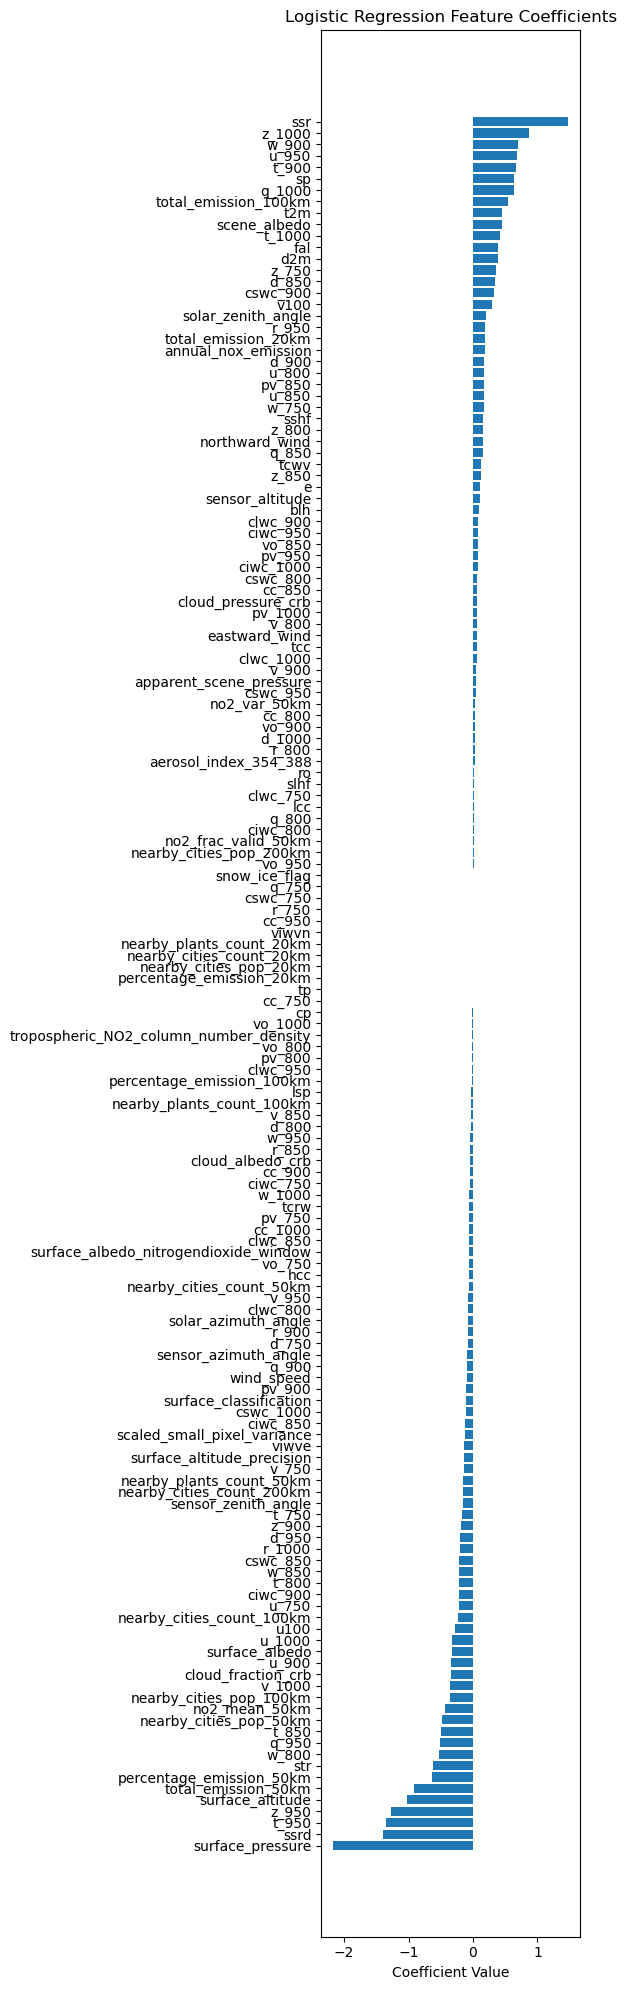

In [123]:
feature_names = X.columns
coefs = model.coef_[0]

# Sort coefficients for better visualization
indices = np.argsort(coefs)

plt.figure(figsize=(6, 20))
plt.barh(feature_names[indices], coefs[indices])
plt.xlabel("Coefficient Value")
plt.title("Logistic Regression Feature Coefficients")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, classification_report,
    cohen_kappa_score
)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# 1) Prepare data
# X = filtered_50.iloc[:, 9:].values.astype(np.float32)
y = filtered_50["plume_label"].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
ros = RandomOverSampler(random_state=42)
X_tr_bal, y_tr_bal = ros.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr_bal)
X_te_s = scaler.transform(X_test)

# 2) Tensors & DataLoaders
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_ds = TensorDataset(torch.from_numpy(X_tr_s), torch.from_numpy(y_tr_bal))
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
test_ds  = TensorDataset(torch.from_numpy(X_te_s), torch.from_numpy(y_test))
test_dl  = DataLoader(test_ds, batch_size=32)

# 3) Model
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

model = MLP(X_tr_s.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 4) Train with early stopping
best_loss = np.inf
patience, counter = 5, 0
num_epochs = 100

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device).float()
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    avg_loss = total_loss / len(train_dl.dataset)

    # print training progress
    print(f"Epoch {epoch+1}/{num_epochs} – train loss: {avg_loss:.4f}")

    if avg_loss < best_loss:
        best_loss, counter = avg_loss, 0
        torch.save(model.state_dict(), 'best.pt')
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(torch.load('best.pt'))

# 5) Evaluate
model.eval()
probs = []
with torch.no_grad():
    for xb, _ in test_dl:
        xb = xb.to(device)
        probs.extend(torch.sigmoid(model(xb)).cpu().numpy())
probs = np.array(probs)
preds = (probs >= 0.5).astype(int)

print("Accuracy:          ", accuracy_score(y_test, preds))
print("Precision:         ", precision_score(y_test, preds))
print("Recall:            ", recall_score(y_test, preds))
print("F1 Score:          ", f1_score(y_test, preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, preds))
print("AUC:               ", roc_auc_score(y_test, probs))
print("Classification Rep:\n", classification_report(y_test, preds))
print("Cohen's Kappa:     ", cohen_kappa_score(y_test, preds))

RuntimeError: mat1 and mat2 must have the same dtype, but got Double and Float

In [60]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report, cohen_kappa_score
import matplotlib.pyplot as plt

# print(X)
X = filtered_20.iloc[:,9:]
# X = filtered_100[:,9:]

y = filtered_20["plume_label"].astype(bool)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Balance training data
ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train, y_train)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression
model = LogisticRegression(max_iter=1000, random_state=42)
# model.fit(X_train_scaled, y_train_bal)
model.fit(X_train_scaled, y_train_bal)

# Evaluate model
y_pred = model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1]))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Kappa:", cohen_kappa_score(y_test, y_pred))


Accuracy: 0.717948717948718
Precision: 0.580952380952381
Recall: 0.7689075630252101
F1 Score: 0.6618444846292948
Confusion Matrix:
 [[293 132]
 [ 55 183]]
AUC: 0.7989520514087988
Classification Report:
               precision    recall  f1-score   support

       False       0.84      0.69      0.76       425
        True       0.58      0.77      0.66       238

    accuracy                           0.72       663
   macro avg       0.71      0.73      0.71       663
weighted avg       0.75      0.72      0.72       663

Kappa: 0.42786538008943287


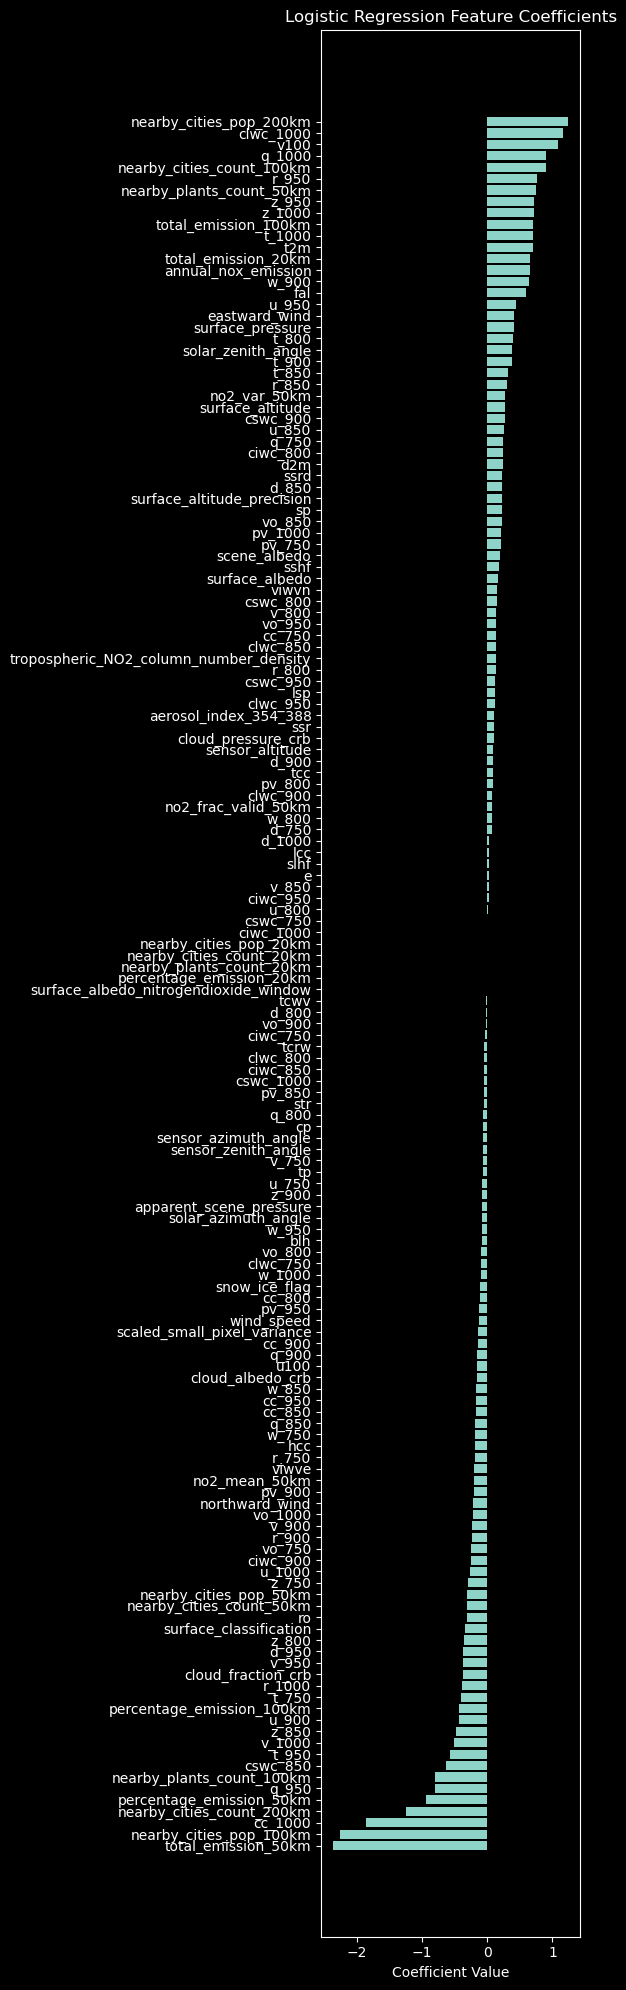

In [61]:
feature_names = X.columns
coefs = model.coef_[0]

# Sort coefficients for better visualization
indices = np.argsort(coefs)

plt.figure(figsize=(6, 20))
plt.barh(feature_names[indices], coefs[indices])
plt.xlabel("Coefficient Value")
plt.title("Logistic Regression Feature Coefficients")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, classification_report,
    cohen_kappa_score
)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# 1) Prepare data
X = filtered_20.iloc[:, 9:].values.astype(np.float32)
y = filtered_20["plume_label"].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
ros = RandomOverSampler(random_state=42)
X_tr_bal, y_tr_bal = ros.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr_bal)
X_te_s = scaler.transform(X_test)

# 2) Tensors & DataLoaders
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_ds = TensorDataset(torch.from_numpy(X_tr_s), torch.from_numpy(y_tr_bal))
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
test_ds  = TensorDataset(torch.from_numpy(X_te_s), torch.from_numpy(y_test))
test_dl  = DataLoader(test_ds, batch_size=32)

# 3) Model
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            # nn.ReLU(),
            # nn.Dropout(0.3),
            # nn.Linear(256, 128),
            # nn.ReLU(),
            # nn.Dropout(0.3),
            # nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

model = MLP(X_tr_s.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# 4) Train with early stopping
best_loss = np.inf
patience, counter = 5, 0
num_epochs = 200

# after optimizer definition
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2, verbose=True
)

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device).float()
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)

    avg_loss = total_loss / len(train_dl.dataset)
    print(f"Epoch {epoch+1}/{num_epochs} – train loss: {avg_loss:.4f}")

    # step the scheduler on the training loss
    scheduler.step(avg_loss)

    # early stopping
    if avg_loss < best_loss:
        best_loss, counter = avg_loss, 0
        torch.save(model.state_dict(), 'best.pt')

model.load_state_dict(torch.load('best.pt'))

# 5) Evaluate
model.eval()
probs = []
with torch.no_grad():
    for xb, _ in test_dl:
        xb = xb.to(device)
        probs.extend(torch.sigmoid(model(xb)).cpu().numpy())
probs = np.array(probs)
preds = (probs >= 0.5).astype(int)

print("Accuracy:          ", accuracy_score(y_test, preds))
print("Precision:         ", precision_score(y_test, preds))
print("Recall:            ", recall_score(y_test, preds))
print("F1 Score:          ", f1_score(y_test, preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, preds))
print("AUC:               ", roc_auc_score(y_test, probs))
print("Classification Rep:\n", classification_report(y_test, preds))
print("Cohen's Kappa:     ", cohen_kappa_score(y_test, preds))

/net/fs01/home/rzhuang/miniforge3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/200 – train loss: 0.6136
Epoch 2/200 – train loss: 0.5445
Epoch 3/200 – train loss: 0.5142
Epoch 4/200 – train loss: 0.4975
Epoch 5/200 – train loss: 0.4803
Epoch 6/200 – train loss: 0.4648
Epoch 7/200 – train loss: 0.4457
Epoch 8/200 – train loss: 0.4373
Epoch 9/200 – train loss: 0.4397
Epoch 10/200 – train loss: 0.4189
Epoch 11/200 – train loss: 0.4093
Epoch 12/200 – train loss: 0.3964
Epoch 13/200 – train loss: 0.3972
Epoch 14/200 – train loss: 0.3880
Epoch 15/200 – train loss: 0.3708
Epoch 16/200 – train loss: 0.3644
Epoch 17/200 – train loss: 0.3685
Epoch 18/200 – train loss: 0.3616
Epoch 19/200 – train loss: 0.3535
Epoch 20/200 – train loss: 0.3386
Epoch 21/200 – train loss: 0.3280
Epoch 22/200 – train loss: 0.3214
Epoch 23/200 – train loss: 0.3306
Epoch 24/200 – train loss: 0.3176
Epoch 25/200 – train loss: 0.3254
Epoch 26/200 – train loss: 0.3134
Epoch 27/200 – train loss: 0.3144
Epoch 28/200 – train loss: 0.2936
Epoch 29/200 – train loss: 0.2978
Epoch 30/200 – train lo

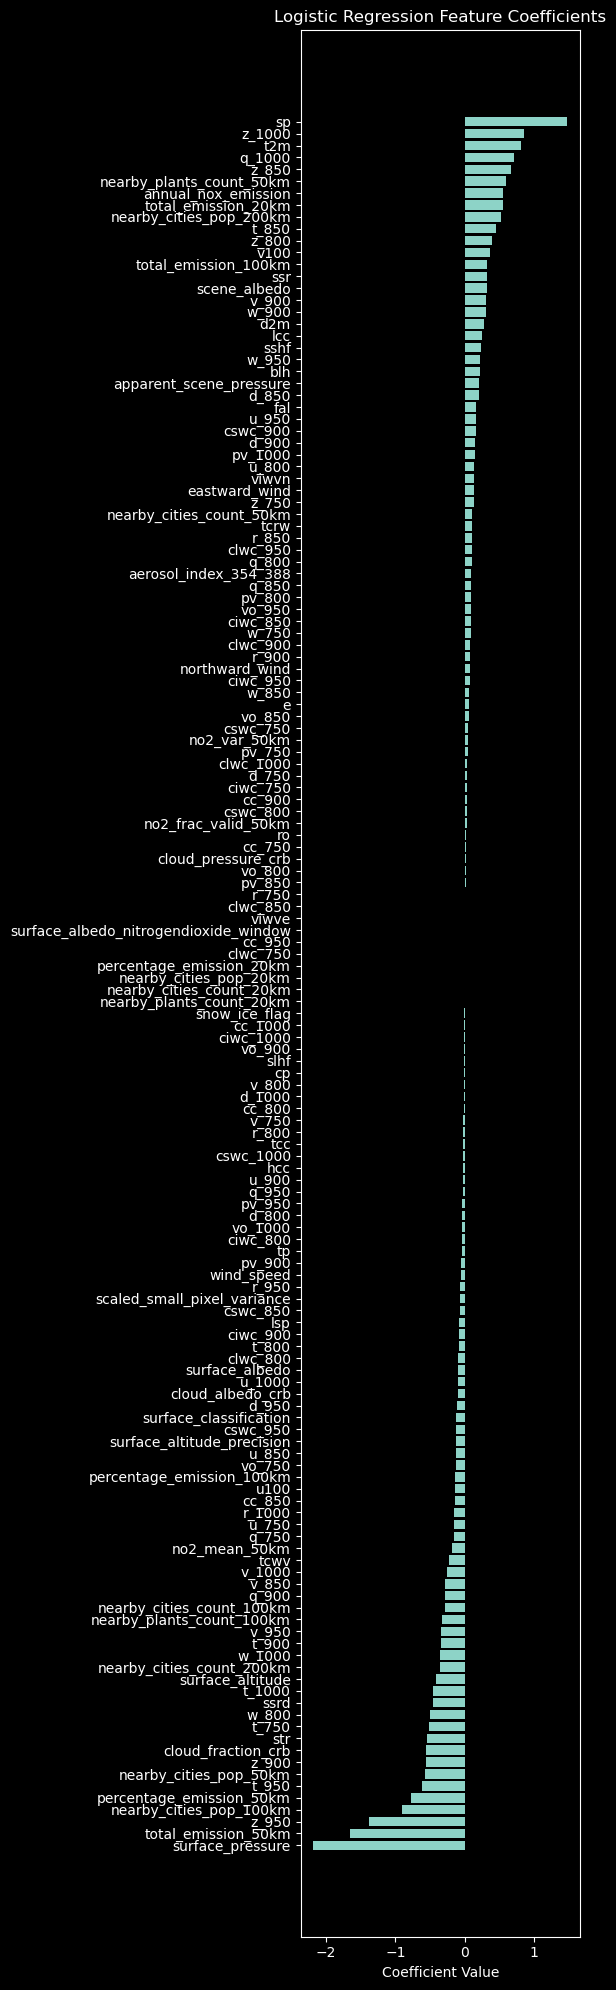

In [16]:
feature_names = X.columns
coefs = model.coef_[0]

# Sort coefficients for better visualization
indices = np.argsort(coefs)

plt.figure(figsize=(6, 20))
plt.barh(feature_names[indices], coefs[indices])
plt.xlabel("Coefficient Value")
plt.title("Logistic Regression Feature Coefficients")
plt.tight_layout()
plt.show()

In [70]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import cohen_kappa_score

# filtered_50 is your DataFrame of 50 plants, with y = plume_label
y = filtered_50['plume_label'].astype(bool)
feature_cols = filtered_50.columns[9:]

results = []
for col in feature_cols:
    X = filtered_50[[col]]
    
    # train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    # simple oversample minority class
    df_tr = X_train.copy()
    df_tr['y'] = y_train
    maj = df_tr['y'].value_counts().idxmax()
    minc = df_tr['y'].value_counts().idxmin()
    maj_df = df_tr[df_tr['y']==maj]
    min_df = df_tr[df_tr['y']==minc]
    min_up = min_df.sample(n=len(maj_df), replace=True, random_state=42)
    df_bal = pd.concat([maj_df, min_up])
    
    X_tr_bal = df_bal[[col]]
    y_tr_bal = df_bal['y']
    
    # scale
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr_bal)
    X_te_s = scaler.transform(X_test)
    
    # train & eval
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_tr_s, y_tr_bal)
    y_pred = model.predict(X_te_s)
    kappa = cohen_kappa_score(y_test, y_pred)
    
    results.append((col, kappa))

# build DataFrame & sort
df_kappa = pd.DataFrame(results, columns=['feature','kappa']) \
             .sort_values('kappa', ascending=False) \
             .reset_index(drop=True)

print(df_kappa)

                       feature     kappa
0       nearby_cities_pop_50km  0.219844
1    nearby_cities_count_100km  0.205296
2      nearby_cities_pop_100km  0.175376
3     nearby_cities_count_50km  0.168926
4     nearby_plants_count_50km  0.167269
..                         ...       ...
147                       v100 -0.023966
148                     v_1000 -0.025390
149                      w_800 -0.034004
150     surface_classification -0.042925
151                        fal -0.044317

[152 rows x 2 columns]


In [26]:
feature_cols = filtered_50.columns[9:]
feature_cols[:26]

Index(['annual_nox_emission', 'no2_mean_50km', 'no2_var_50km',
       'no2_frac_valid_50km', 'surface_altitude', 'surface_altitude_precision',
       'surface_classification', 'surface_pressure', 'surface_albedo',
       'surface_albedo_nitrogendioxide_window', 'cloud_pressure_crb',
       'cloud_fraction_crb', 'cloud_albedo_crb', 'scene_albedo',
       'apparent_scene_pressure', 'snow_ice_flag', 'aerosol_index_354_388',
       'eastward_wind', 'northward_wind', 'scaled_small_pixel_variance',
       'tropospheric_NO2_column_number_density', 'sensor_altitude',
       'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle',
       'solar_zenith_angle'],
      dtype='object')

In [77]:
feature_cols = filtered_50.columns[9:]

feature_names = ['annual_nox_emission', 'no2_mean_50km', 'no2_std_50km', 'no2_frac_valid_50km', 
        'surface_pressure', 'cloud_fraction_crb', 'wind_speed', 'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle', 'surface_albedo_nitrogendioxide_window', 'solar_zenith_angle','nearby_plants_count_100km', 'total_emission_100km', 'nearby_cities_pop_100km', 'apparent_scene_pressure',
        't2m']

# Subset X to those top 60
X = tropomi_combined_dropna[feature_names]
y = tropomi_combined_dropna['plume_label'].astype(bool)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# simple oversample minority class
df_tr = X_train.copy(); df_tr['y'] = y_train
maj = df_tr['y'].value_counts().idxmax()
minc = df_tr['y'].value_counts().idxmin()
maj_df = df_tr[df_tr['y']==maj]
min_df = df_tr[df_tr['y']==minc]
min_up = min_df.sample(n=len(maj_df), replace=True, random_state=42)
df_bal = pd.concat([maj_df, min_up])
X_tr_bal = df_bal[feature_names]
y_tr_bal = df_bal['y']

# Scale
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr_bal)
X_te_s = scaler.transform(X_test)

# Train & evaluate
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_tr_s, y_tr_bal)
y_pred = model.predict(X_te_s)

print("Accuracy:",      accuracy_score(y_test, y_pred))
print("Precision:",     precision_score(y_test, y_pred))
print("Recall:",        recall_score(y_test, y_pred))
print("F1 Score:",      f1_score(y_test, y_pred))
print("Confusion:\n",   confusion_matrix(y_test, y_pred))
print("AUC:",           roc_auc_score(y_test, model.predict_proba(X_te_s)[:,1]))
print("Classification:\n", classification_report(y_test, y_pred))
print("Kappa:",         cohen_kappa_score(y_test, y_pred))

Accuracy: 0.7271237351241463
Precision: 0.17950028392958547
Recall: 0.6812010631420157
F1 Score: 0.2841305748228491
Confusion:
 [[117848  43347]
 [  4438   9483]]
AUC: 0.7745751100727986
Classification:
               precision    recall  f1-score   support

       False       0.96      0.73      0.83    161195
        True       0.18      0.68      0.28     13921

    accuracy                           0.73    175116
   macro avg       0.57      0.71      0.56    175116
weighted avg       0.90      0.73      0.79    175116

Kappa: 0.1810831230949178


In [ ]:
feature_cols = filtered_50.columns[9:]

feature_names = ['annual_nox_emission', 'no2_mean_50km', 'no2_std_50km', 'no2_frac_valid_50km', 
        'surface_pressure', 'cloud_fraction_crb', 'wind_speed', 'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle', 'surface_albedo_nitrogendioxide_window', 'solar_zenith_angle','nearby_plants_count_100km', 'total_emission_100km', 'nearby_cities_pop_100km', 'apparent_scene_pressure', 't2m']

# Subset X to those top 60
X = filtered_100[feature_names]
y = filtered_100['plume_label'].astype(bool)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# simple oversample minority class
df_tr = X_train.copy(); df_tr['y'] = y_train
maj = df_tr['y'].value_counts().idxmax()
minc = df_tr['y'].value_counts().idxmin()
maj_df = df_tr[df_tr['y']==maj]
min_df = df_tr[df_tr['y']==minc]
min_up = min_df.sample(n=len(maj_df), replace=True, random_state=42)
df_bal = pd.concat([maj_df, min_up])
X_tr_bal = df_bal[feature_names]
y_tr_bal = df_bal['y']

# Scale
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr_bal)
X_te_s = scaler.transform(X_test)

# Train & evaluate
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_tr_s, y_tr_bal)
y_pred = model.predict(X_te_s)

print("Accuracy:",      accuracy_score(y_test, y_pred))
print("Precision:",     precision_score(y_test, y_pred))
print("Recall:",        recall_score(y_test, y_pred))
print("F1 Score:",      f1_score(y_test, y_pred))
print("Confusion:\n",   confusion_matrix(y_test, y_pred))
print("AUC:",           roc_auc_score(y_test, model.predict_proba(X_te_s)[:,1]))
print("Classification:\n", classification_report(y_test, y_pred))
print("Kappa:",         cohen_kappa_score(y_test, y_pred))

Accuracy: 0.612565445026178
Precision: 0.47158403869407495
Recall: 0.7155963302752294
F1 Score: 0.5685131195335277
Confusion:
 [[1092  874]
 [ 310  780]]
AUC: 0.673149504885811
Classification:
               precision    recall  f1-score   support

       False       0.78      0.56      0.65      1966
        True       0.47      0.72      0.57      1090

    accuracy                           0.61      3056
   macro avg       0.63      0.64      0.61      3056
weighted avg       0.67      0.61      0.62      3056

Kappa: 0.24302376764246603


In [80]:
feature_cols = filtered_50.columns[9:]

feature_names = ['annual_nox_emission', 'no2_mean_50km', 'no2_std_50km', 'no2_frac_valid_50km', 
        'surface_pressure', 'cloud_fraction_crb', 'wind_speed', 'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle', 'surface_albedo_nitrogendioxide_window', 'solar_zenith_angle','nearby_plants_count_100km', 'total_emission_100km',  'nearby_cities_pop_100km', 'apparent_scene_pressure', 't2m']

# Subset X to those top 60
X = filtered_50[feature_names]
y = filtered_50['plume_label'].astype(bool)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# simple oversample minority class
df_tr = X_train.copy(); df_tr['y'] = y_train
maj = df_tr['y'].value_counts().idxmax()
minc = df_tr['y'].value_counts().idxmin()
maj_df = df_tr[df_tr['y']==maj]
min_df = df_tr[df_tr['y']==minc]
min_up = min_df.sample(n=len(maj_df), replace=True, random_state=42)
df_bal = pd.concat([maj_df, min_up])
X_tr_bal = df_bal[feature_names]
y_tr_bal = df_bal['y']

# Scale
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr_bal)
X_te_s = scaler.transform(X_test)

# Train & evaluate
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_tr_s, y_tr_bal)
y_pred = model.predict(X_te_s)

print("Accuracy:",      accuracy_score(y_test, y_pred))
print("Precision:",     precision_score(y_test, y_pred))
print("Recall:",        recall_score(y_test, y_pred))
print("F1 Score:",      f1_score(y_test, y_pred))
print("Confusion:\n",   confusion_matrix(y_test, y_pred))
print("AUC:",           roc_auc_score(y_test, model.predict_proba(X_te_s)[:,1]))
print("Classification:\n", classification_report(y_test, y_pred))
print("Kappa:",         cohen_kappa_score(y_test, y_pred))

Accuracy: 0.6765615337043909
Precision: 0.5879574970484062
Recall: 0.7410714285714286
F1 Score: 0.6556945358788677
Confusion:
 [[596 349]
 [174 498]]
AUC: 0.7358812043335853
Classification:
               precision    recall  f1-score   support

       False       0.77      0.63      0.70       945
        True       0.59      0.74      0.66       672

    accuracy                           0.68      1617
   macro avg       0.68      0.69      0.68      1617
weighted avg       0.70      0.68      0.68      1617

Kappa: 0.3582822085889571


In [ ]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report, cohen_kappa_score

# Get all available features
all_features = filtered_100.columns[9:].tolist()

# Your current baseline features
base_features = ['annual_nox_emission', 'no2_mean_50km', 'no2_var_50km', 'surface_altitude', 'sensor_altitude', 'surface_classification', 'wind_speed', 'surface_albedo', 'scene_albedo', 'cloud_fraction_crb', 'fal', 'sp', 'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle', 'solar_zenith_angle', 'hcc', 'tcc', 'sshf', 'str', 'd2m', 'viwve', 'cc_850', 'nearby_plants_count_100km', 'total_emission_100km', 'percentage_emission_100km', 'nearby_cities_count_100km', 'nearby_cities_pop_100km', 'r_1000', 'd_850', 'd_800', 'vo_950', 't_850']

print("Base features:", base_features)
# base results
X = filtered_50[base_features]
y = filtered_50['plume_label'].astype(bool)
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Simple oversample minority class
df_tr = X_train.copy(); df_tr['y'] = y_train
maj = df_tr['y'].value_counts().idxmax()
minc = df_tr['y'].value_counts().idxmin()
maj_df = df_tr[df_tr['y']==maj]
min_df = df_tr[df_tr['y']==minc]
min_up = min_df.sample(n=len(maj_df), replace=True, random_state=42)
df_bal = pd.concat([maj_df, min_up])
X_tr_bal = df_bal[base_features]
y_tr_bal = df_bal['y']
# Scale
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr_bal)
X_te_s = scaler.transform(X_test)
# Train & evaluate
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_tr_s, y_tr_bal)
y_pred = model.predict(X_te_s)
print("Base model performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion:\n", confusion_matrix(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, model.predict_proba(X_te_s)[:,1]))
print("Classification:\n", classification_report(y_test, y_pred))
print("Kappa:", cohen_kappa_score(y_test, y_pred))

# Features to test (exclude those already in the baseline)
features_to_test = [f for f in all_features if f not in base_features]

results = []

# Test each additional feature
for feature in features_to_test:
    # Create feature set with the new feature added
    test_features = base_features + [feature]
    
    # Subset data
    X = filtered_50[test_features]
    y = filtered_50['plume_label'].astype(bool)
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    # Simple oversample minority class
    df_tr = X_train.copy(); df_tr['y'] = y_train
    maj = df_tr['y'].value_counts().idxmax()
    minc = df_tr['y'].value_counts().idxmin()
    maj_df = df_tr[df_tr['y']==maj]
    min_df = df_tr[df_tr['y']==minc]
    min_up = min_df.sample(n=len(maj_df), replace=True, random_state=42)
    df_bal = pd.concat([maj_df, min_up])
    X_tr_bal = df_bal[test_features]
    y_tr_bal = df_bal['y']
    
    # Scale
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr_bal)
    X_te_s = scaler.transform(X_test)
    
    # Train & evaluate
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_tr_s, y_tr_bal)
    y_pred = model.predict(X_te_s)
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_te_s)[:,1])
    
    # Store results
    results.append({
        'feature': feature,
        'accuracy': acc,
        'f1_score': f1,
        'kappa': kappa,
        'auc': auc
    })
    
    print(f"Tested: {feature}, Accuracy: {acc:.4f}, F1: {f1:.4f}, Kappa: {kappa:.4f}, AUC: {auc:.4f}")

# Convert to DataFrame and sort by accuracy
results_df = pd.DataFrame(results).sort_values('accuracy', ascending=False)

# Display top 10 features
print("\nTop 10 features by accuracy:")
print(results_df.head(10))

# Get the best feature
best_feature = results_df.iloc[0]['feature']
print(f"\nBest feature to add: {best_feature}")

# Build final model with best feature added
best_features = base_features + [best_feature]
print(f"\nFinal feature set: {best_features}")

# Train and evaluate the model with the best feature added
X = filtered_50[best_features]
y = filtered_50['plume_label'].astype(bool)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Simple oversample minority class
df_tr = X_train.copy(); df_tr['y'] = y_train
maj = df_tr['y'].value_counts().idxmax()
minc = df_tr['y'].value_counts().idxmin()
maj_df = df_tr[df_tr['y']==maj]
min_df = df_tr[df_tr['y']==minc]
min_up = min_df.sample(n=len(maj_df), replace=True, random_state=42)
df_bal = pd.concat([maj_df, min_up])
X_tr_bal = df_bal[best_features]
y_tr_bal = df_bal['y']

# Scale
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr_bal)
X_te_s = scaler.transform(X_test)

# Train & evaluate
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_tr_s, y_tr_bal)
y_pred = model.predict(X_te_s)

print("\nFinal model performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion:\n", confusion_matrix(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, model.predict_proba(X_te_s)[:,1]))
print("Classification:\n", classification_report(y_test, y_pred))
print("Kappa:", cohen_kappa_score(y_test, y_pred))

Base features: ['annual_nox_emission', 'no2_mean_50km', 'no2_var_50km', 'surface_altitude', 'sensor_altitude', 'surface_classification', 'wind_speed', 'surface_albedo', 'scene_albedo', 'cloud_fraction_crb', 'fal', 'sp', 'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle', 'solar_zenith_angle', 'hcc', 'tcc', 'sshf', 'str', 'd2m', 'viwve', 'cc_850', 'nearby_plants_count_100km', 'total_emission_100km', 'percentage_emission_100km', 'nearby_cities_count_100km', 'nearby_cities_pop_100km', 'r_1000', 'd_850', 'd_800', 'vo_950', 't_850']
Base model performance:
Accuracy: 0.7105751391465677
Precision: 0.6197183098591549
Recall: 0.7857142857142857
F1 Score: 0.6929133858267716
Confusion:
 [[621 324]
 [144 528]]
AUC: 0.7594356261022928
Classification:
               precision    recall  f1-score   support

       False       0.81      0.66      0.73       945
        True       0.62      0.79      0.69       672

    accuracy                           0.71      1617
   macro avg   

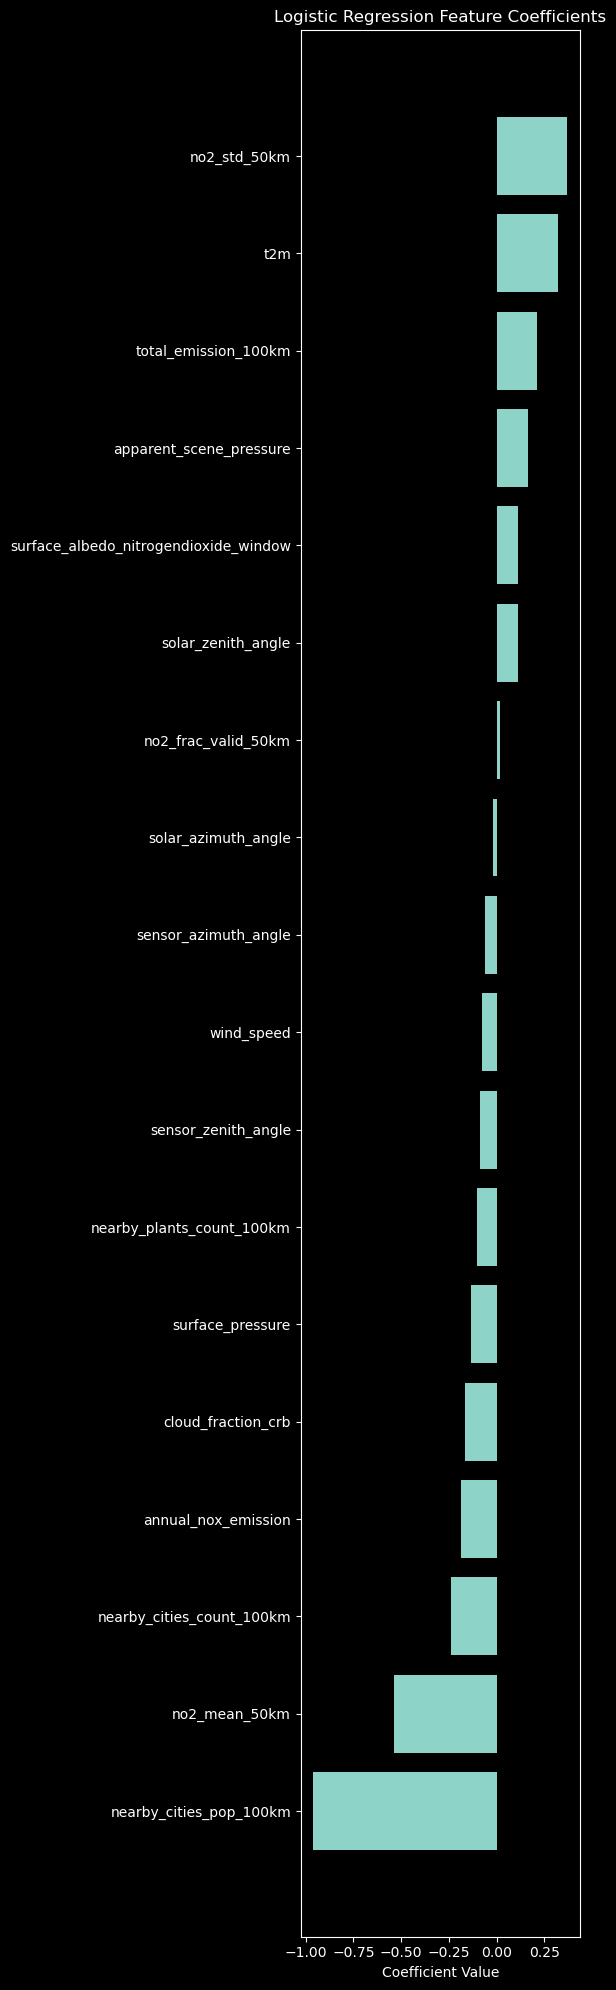

In [58]:
feature_names = X.columns
coefs = model.coef_[0]

# Sort coefficients for better visualization
indices = np.argsort(coefs)

plt.figure(figsize=(6, 20))
plt.barh(feature_names[indices], coefs[indices])
plt.xlabel("Coefficient Value")
plt.title("Logistic Regression Feature Coefficients")
plt.tight_layout()
plt.show()

In [81]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler
import shap

# 0. define your feature sets
all_features = filtered_50.columns[9:].tolist()

base_features = ['annual_nox_emission', 'no2_mean_50km', 'no2_std_50km', 'no2_frac_valid_50km', 
        'surface_pressure', 'cloud_fraction_crb', 'wind_speed', 'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle', 'surface_albedo_nitrogendioxide_window', 'solar_zenith_angle','nearby_plants_count_100km', 'total_emission_100km', 'nearby_cities_pop_100km', 'apparent_scene_pressure', 't2m']

# (optional) extras you might test separately
features_to_test = [f for f in all_features if f not in base_features]

# 1. choose your model inputs
features = base_features  # or all_features, or base_features + features_to_test
X = filtered_100[features]
y = filtered_100['plume_label'].astype(bool)
plant_ids = filtered_100['location']

# 2. split
X_train, X_test, y_train, y_test, pid_train, pid_test = train_test_split(
    X, y, plant_ids, test_size=0.2, random_state=42
)

# 3. balance
ros = RandomOverSampler(random_state=42)
X_tr_bal, y_tr_bal = ros.fit_resample(X_train, y_train)

# 4. scale
scaler = StandardScaler().fit(X_tr_bal)
X_tr_s = scaler.transform(X_tr_bal)
X_te_s = scaler.transform(X_test)

# 5. train
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_tr_s, y_tr_bal)

# 6. explain with SHAP
explainer = shap.Explainer(model, X_tr_s, feature_names=features)
shap_vals = explainer(X_te_s)  # (n_samples, n_features)

# 7. aggregate per‐plant
shap_abs = np.abs(shap_vals.values)
shap_df = pd.DataFrame(shap_abs, columns=features, index=X_test.index)
shap_df['plant_id'] = pid_test.values

mean_by_plant = shap_df.groupby('plant_id')[features].mean()
top_feature_per_plant = mean_by_plant.idxmax(axis=1)

# 8. result
print(top_feature_per_plant)

plant_id
CoCO2_00016    nearby_cities_pop_100km
CoCO2_00197    nearby_cities_pop_100km
CoCO2_00198    nearby_cities_pop_100km
CoCO2_00216    nearby_cities_pop_100km
CoCO2_00510    nearby_cities_pop_100km
                        ...           
CoCO2_15066    nearby_cities_pop_100km
CoCO2_15078    nearby_cities_pop_100km
CoCO2_15294           surface_pressure
CoCO2_15540           surface_pressure
CoCO2_15662    nearby_cities_pop_100km
Length: 100, dtype: object


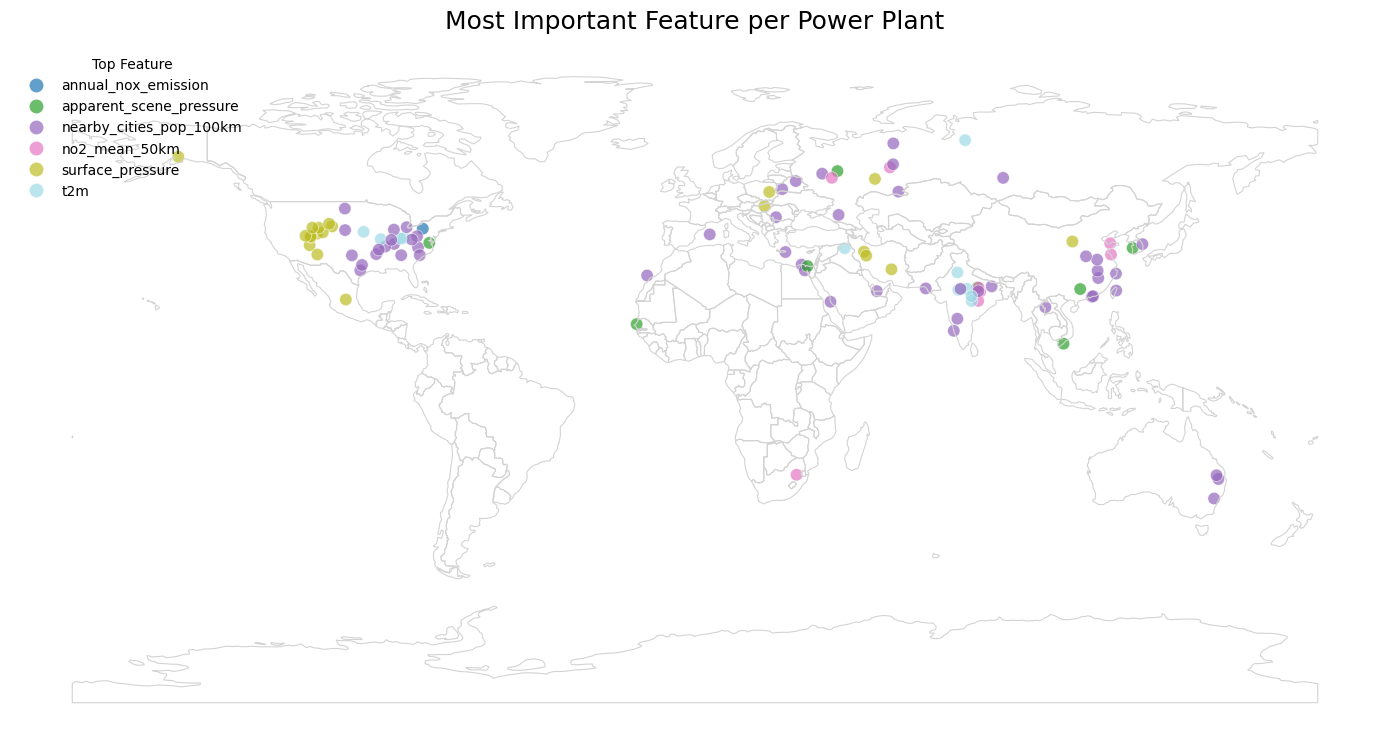

In [83]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
plt.rcdefaults()

# 1. Prepare coords + result
coords = (
    filtered_100[['location','latitude','longitude']]
    .drop_duplicates()
    .rename(columns={'location':'plant_id'})
)
result = (
    top_feature_per_plant
    .rename('top_feature')
    .reset_index()
    .rename(columns={'index':'plant_id'})
)
plot_df = pd.merge(result, coords, on='plant_id')

# 2. GeoDataFrame of plants
gdf = gpd.GeoDataFrame(
    plot_df,
    geometry=gpd.points_from_xy(plot_df.longitude, plot_df.latitude),
    crs="EPSG:4326"
)

# 3. Load world geometry from an online GeoJSON
world = gpd.read_file(
    "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
)

# 4. Pretty‐plot
fig, ax = plt.subplots(figsize=(14,8))
ax.set_facecolor("#f5f5f5")

world.boundary.plot(ax=ax, color="lightgray", linewidth=0.8)

gdf.plot(
    ax=ax,
    column="top_feature",
    categorical=True,
    legend=True,
    legend_kwds={
        "title": "Top Feature",
        "loc": "upper left",
        "frameon": False,
        "fontsize": 10,
    },
    cmap="tab20",
    markersize=80,
    alpha=0.7,
    edgecolor="white",
    linewidth=0.5
)

ax.set_title("Most Important Feature per Power Plant", fontsize=18, pad=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [47]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, cohen_kappa_score
from imblearn.over_sampling import RandomOverSampler

base_features = ['annual_nox_emission', 'no2_mean_50km', 'no2_var_50km',
       'no2_frac_valid_50km', 'surface_altitude', 'surface_pressure', 'surface_albedo',
       'surface_albedo_nitrogendioxide_window', 'cloud_fraction_crb', 
       'wind_speed', 'sensor_altitude',
       'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle',
       'solar_zenith_angle', 'total_emission_100km', 
       'percentage_emission_100km', 'nearby_cities_count_100km', 'nearby_cities_pop_100km',
       'z_750', 'ssr', 'pv_950', 'd2m']
# base_features = ['annual_nox_emission', 'no2_mean_50km', 'surface_altitude', 'surface_altitude_precision', 'surface_classification', 'surface_albedo', 'cloud_fraction_crb', 'scene_albedo', 'apparent_scene_pressure', 'northward_wind', 'scaled_small_pixel_variance', 'sensor_altitude', 'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle', 'solar_zenith_angle', 'e', 'hcc', 'tcc', 'sshf', 'ssrd', 'str', 'd2m', 'tcwv', 'viwvn', 'viwve', 'nearby_plants_count_100km', 'total_emission_100km', 'percentage_emission_100km', 'nearby_cities_count_100km', 'nearby_cities_pop_100km']

results = []
for feat in base_features:
    feats = [f for f in base_features if f != feat]
    X = filtered_100[feats].values
    y = filtered_100['plume_label'].astype(bool).values

    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
    X_tr_bal, y_tr_bal = RandomOverSampler(random_state=42).fit_resample(X_tr, y_tr)

    scaler = StandardScaler().fit(X_tr_bal)
    X_tr_s = scaler.transform(X_tr_bal)
    X_te_s = scaler.transform(X_te)

    model = LogisticRegression(max_iter=1000, random_state=42).fit(X_tr_s, y_tr_bal)
    y_pred = model.predict(X_te_s)
    probs = model.predict_proba(X_te_s)[:,1]

    results.append({
        'dropped': feat,
        'auc': roc_auc_score(y_te, probs),
        'f1': f1_score(y_te, y_pred),
        'kappa': cohen_kappa_score(y_te, y_pred)
    })

df = pd.DataFrame(results).sort_values('auc', ascending=False)
print(df.head(10))

                      dropped       auc        f1     kappa
11       sensor_azimuth_angle  0.685924  0.560000  0.245101
22                        d2m  0.685149  0.563284  0.249866
3         no2_frac_valid_50km  0.684786  0.560641  0.246639
0         annual_nox_emission  0.684640  0.559878  0.245331
2                no2_var_50km  0.684632  0.560548  0.245896
6              surface_albedo  0.684608  0.557678  0.242147
21                     pv_950  0.684112  0.562047  0.249486
13        solar_azimuth_angle  0.684043  0.558565  0.243227
17  nearby_cities_count_100km  0.683832  0.561524  0.247716
8          cloud_fraction_crb  0.683591  0.556607  0.236931


In [45]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report, cohen_kappa_score
import matplotlib.pyplot as plt

# print(X)
X = filtered_20.iloc[:,9:]
# X = filtered_100[:,9:]

y = filtered_20["plume_label"].astype(bool)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Balance training data
ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train, y_train)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression
model = LogisticRegression(max_iter=1000, random_state=42)
# model.fit(X_train_scaled, y_train_bal)
model.fit(X_train_scaled, y_train_bal)

# Evaluate model
y_pred = model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1]))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Kappa:", cohen_kappa_score(y_test, y_pred))


Accuracy: 0.717948717948718
Precision: 0.580952380952381
Recall: 0.7689075630252101
F1 Score: 0.6618444846292948
Confusion Matrix:
 [[293 132]
 [ 55 183]]
AUC: 0.7989520514087988
Classification Report:
               precision    recall  f1-score   support

       False       0.84      0.69      0.76       425
        True       0.58      0.77      0.66       238

    accuracy                           0.72       663
   macro avg       0.71      0.73      0.71       663
weighted avg       0.75      0.72      0.72       663

Kappa: 0.42786538008943287


In [72]:
df_kappa[:60]

,feature,kappa
0,nearby_cities_pop_50km,0.219844
1,nearby_cities_count_100km,0.205296
2,nearby_cities_pop_100km,0.175376
3,nearby_cities_count_50km,0.168926
4,nearby_plants_count_50km,0.167269
5,total_emission_50km,0.154589
6,nearby_cities_count_200km,0.147380
7,pv_800,0.146835
8,sp,0.145796
9,surface_altitude,0.143417


In [21]:
features = df_kappa.head(60)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score,
    classification_report, cohen_kappa_score
)

# — assume you already have `df_kappa` from your single‐feature run —
# df_kappa = pd.DataFrame(...).sort_values('kappa', ascending=False)

top60 = df_kappa['feature'].iloc[:60].tolist()

# Subset X to those top 60
X = filtered_50[top60]
y = filtered_50['plume_label'].astype(bool)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# simple oversample minority class
df_tr = X_train.copy(); df_tr['y'] = y_train
maj = df_tr['y'].value_counts().idxmax()
minc = df_tr['y'].value_counts().idxmin()
maj_df = df_tr[df_tr['y']==maj]
min_df = df_tr[df_tr['y']==minc]
min_up = min_df.sample(n=len(maj_df), replace=True, random_state=42)
df_bal = pd.concat([maj_df, min_up])
X_tr_bal = df_bal[top60]
y_tr_bal = df_bal['y']

# Scale
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr_bal)
X_te_s = scaler.transform(X_test)

# Train & evaluate
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_tr_s, y_tr_bal)
y_pred = model.predict(X_te_s)

print("Accuracy:",      accuracy_score(y_test, y_pred))
print("Precision:",     precision_score(y_test, y_pred))
print("Recall:",        recall_score(y_test, y_pred))
print("F1 Score:",      f1_score(y_test, y_pred))
print("Confusion:\n",   confusion_matrix(y_test, y_pred))
print("AUC:",           roc_auc_score(y_test, model.predict_proba(X_te_s)[:,1]))
print("Classification:\n", classification_report(y_test, y_pred))
print("Kappa:",         cohen_kappa_score(y_test, y_pred))

NameError: name 'df_kappa' is not defined

In [23]:
X

,annual_nox_emission,no2_mean_50km,no2_var_50km,no2_frac_valid_50km,surface_altitude,surface_altitude_precision,surface_classification,surface_pressure,surface_albedo,surface_albedo_nitrogendioxide_window,...,percentage_emission_100km,nearby_cities_count_20km,nearby_cities_pop_20km,nearby_cities_count_50km,nearby_cities_pop_50km,nearby_cities_count_100km,nearby_cities_pop_100km,nearby_cities_count_200km,nearby_cities_pop_200km,wind_speed
33,7434.580038,0.000035,2.109658e-09,0.939021,956.342346,37.361210,110.0,91159.945312,0.154484,0.033501,...,100.000000,0.0,0.0,0.0,0.0,0.0,0.0,4.0,5602076.0,1.512781
749,7920.364302,0.000034,1.228228e-10,0.867774,578.838562,12.452729,68.0,94178.671875,0.153721,0.075477,...,88.886898,0.0,0.0,2.0,439517.0,6.0,1036166.0,39.0,8624668.0,3.255436
757,6781.811933,0.000050,2.841916e-09,0.916543,296.780304,7.710897,46.0,96850.460938,0.203627,0.089281,...,23.394809,0.0,0.0,4.0,1789485.0,9.0,4518557.0,15.0,5710416.0,1.406202
758,6534.300549,0.000048,9.953696e-10,0.910098,327.661774,8.205189,20.0,96592.648438,0.237817,0.085836,...,44.594595,0.0,0.0,2.0,212411.0,8.0,1819120.0,25.0,4879640.0,0.509581
759,6534.300549,0.000060,2.382016e-10,0.932452,94.046570,9.086280,22.0,99249.070312,0.247649,0.091955,...,48.600884,0.0,0.0,1.0,1536218.0,7.0,4832711.0,25.0,8479916.0,3.976649
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
874401,7029.277276,0.000033,1.487917e-09,0.929147,1943.386353,121.723015,68.0,80563.367188,0.188049,0.097160,...,100.000000,0.0,0.0,1.0,520944.0,6.0,1199358.0,14.0,4404825.0,3.571159
874608,10545.471125,0.000079,7.137360e-10,0.983057,1.101852,1.398971,126.0,101863.656250,0.046795,0.067584,...,25.588247,0.0,0.0,4.0,592890.0,26.0,11378224.0,61.0,46809796.0,4.704830
874609,10545.471125,0.000193,2.490364e-08,0.987064,386.992889,24.505028,148.0,97423.148438,0.425920,0.145885,...,19.195894,0.0,0.0,4.0,1011379.0,26.0,33481872.0,66.0,43907582.0,0.986326
874619,7765.458864,0.000040,8.172821e-10,1.018173,5.150510,3.858136,150.0,101358.906250,0.115345,0.114428,...,10.700392,0.0,0.0,1.0,4697000.0,2.0,7124924.0,6.0,7988490.0,7.377010


Exception ignored in: <function ResourceTracker.__del__ at 0x155301cb7060>
Traceback (most recent call last):
  File "/net/fs01/home/rzhuang/miniforge3/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/net/fs01/home/rzhuang/miniforge3/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/net/fs01/home/rzhuang/miniforge3/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x148913a3b060>
Traceback (most recent call last):
  File "/net/fs01/home/rzhuang/miniforge3/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/net/fs01/home/rzhuang/miniforge3/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/net/fs01/home/rzhuang/miniforge3/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No 

In [61]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFECV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score,
    classification_report, cohen_kappa_score
)

# 1) Load & filter power plants
# power_plants = pd.read_csv(
#     '/net/fs06/d3/rzhuang/TROPOMI_world/data/power_plant_location/power_plants_with_combined_nearby_stats.csv'
# )
# assume `filtered_50` is defined elsewhere, e.g. a subset of `power_plants`
# 2) Prepare X and y
# X = filtered_50.iloc[:, 9:]
X = filtered_50.iloc[:, 9:]\
       .loc[:, ~filtered_50.iloc[:, 9:].columns.str.match(r'.*_\d+$')]
y = filtered_50['plume_label'].astype(bool)

# 3) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4) Oversample minority class on the training set
df_tr = X_train.copy()
df_tr['y'] = y_train
counts = df_tr['y'].value_counts()
maj_df = df_tr[df_tr['y'] == counts.idxmax()]
min_df = df_tr[df_tr['y'] == counts.idxmin()]
min_up = min_df.sample(n=len(maj_df), replace=True, random_state=42)
df_bal = pd.concat([maj_df, min_up])

feature_cols = X_train.columns
X_tr_bal = df_bal[feature_cols]
y_tr_bal = df_bal['y']

# 5) Pre-filter highly correlated features (drop one of any pair with |corr| > 0.9)
corr_matrix = X_tr_bal.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
X_tr_bal = X_tr_bal.drop(columns=to_drop)
# apply same drop to X_test
X_test = X_test.drop(columns=to_drop)
feature_cols = X_tr_bal.columns

# 6) Scale features
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr_bal)
X_te_s = scaler.transform(X_test[feature_cols])

# 7) RFECV with larger step and a minimum feature target
estimator = LogisticRegression(max_iter=1000, random_state=42)
rfecv = RFECV(
    estimator=estimator,
    step=10,                      # drop 5 features per iteration
    scoring='roc_auc',
    min_features_to_select=20,   # stop once ~20 features remain
    n_jobs=-1
)
rfecv.fit(X_tr_s, y_tr_bal)

selected_feats = list(feature_cols[rfecv.support_])
print(f"RFECV selected {len(selected_feats)} features:", selected_feats)

# 8) Train final model on selected features
support = rfecv.support_
X_train_sel = X_tr_s[:, support]
X_test_sel  = X_te_s[:, support]

final_model = LogisticRegression(max_iter=1000, random_state=42)
final_model.fit(X_train_sel, y_tr_bal)

# 9) Evaluate
y_pred = final_model.predict(X_test_sel)
print("Accuracy:          ", accuracy_score(y_test, y_pred))
print("Precision:         ", precision_score(y_test, y_pred))
print("Recall:            ", recall_score(y_test, y_pred))
print("F1 Score:          ", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("AUC:               ", roc_auc_score(y_test, final_model.predict_proba(X_test_sel)[:,1]))
print("Classification Rep:\n", classification_report(y_test, y_pred))
print("Cohen's Kappa:     ", cohen_kappa_score(y_test, y_pred))

RFECV selected 39 features: ['annual_nox_emission', 'no2_mean_50km', 'surface_altitude', 'surface_altitude_precision', 'surface_classification', 'surface_albedo', 'cloud_fraction_crb', 'scene_albedo', 'apparent_scene_pressure', 'northward_wind', 'scaled_small_pixel_variance', 'sensor_altitude', 'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle', 'solar_zenith_angle', 'blh', 'e', 'hcc', 'tcc', 'sshf', 'ssrd', 'str', 'd2m', 'tcwv', 'viwvn', 'viwve', 'nearby_plants_count_50km', 'total_emission_50km', 'percentage_emission_50km', 'nearby_plants_count_100km', 'total_emission_100km', 'percentage_emission_100km', 'nearby_cities_count_50km', 'nearby_cities_pop_50km', 'nearby_cities_count_100km', 'nearby_cities_pop_100km', 'nearby_cities_count_200km', 'nearby_cities_pop_200km']
Accuracy:           0.6982065553494124
Precision:          0.6161616161616161
Recall:             0.7261904761904762
F1 Score:           0.6666666666666666
Confusion Matrix:
 [[641 304]
 [184 488]]
AUC: 

In [62]:
# assume:
#   X_tr_s: np.ndarray shape (n_samples, n_feats)
#   X_te_s: np.ndarray shape (n_samples, n_feats)
#   feature_cols: Index of column names, len= n_feats
#   y_tr_bal: labels

from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression

# 1a) fit on the scaled array
l1 = LogisticRegression(penalty='l1', solver='saga',
                        C=0.1, max_iter=1000, random_state=42)
sfm_l1 = SelectFromModel(estimator=l1, threshold='median')
sfm_l1.fit(X_tr_s, y_tr_bal)

mask = sfm_l1.get_support()              # boolean mask length n_feats
X_train_l1 = X_tr_s[:, mask]
X_test_l1  = X_te_s[:, mask]
selected_feats_l1 = feature_cols[mask]
print("L1 selected", len(selected_feats_l1), "features:", list(selected_feats_l1))

L1 selected 30 features: ['annual_nox_emission', 'no2_mean_50km', 'surface_altitude', 'surface_altitude_precision', 'surface_classification', 'cloud_fraction_crb', 'apparent_scene_pressure', 'northward_wind', 'scaled_small_pixel_variance', 'sensor_altitude', 'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_zenith_angle', 'e', 'sshf', 'ssrd', 'str', 'd2m', 't2m', 'tcwv', 'viwvn', 'viwve', 'nearby_plants_count_50km', 'total_emission_50km', 'percentage_emission_50km', 'total_emission_100km', 'percentage_emission_100km', 'nearby_cities_pop_50km', 'nearby_cities_count_100km', 'nearby_cities_pop_100km']


Exception ignored in: <function ResourceTracker.__del__ at 0x149b64b83060>
Traceback (most recent call last):
  File "/net/fs01/home/rzhuang/miniforge3/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/net/fs01/home/rzhuang/miniforge3/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/net/fs01/home/rzhuang/miniforge3/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x14960c44f060>
Traceback (most recent call last):
  File "/net/fs01/home/rzhuang/miniforge3/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/net/fs01/home/rzhuang/miniforge3/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/net/fs01/home/rzhuang/miniforge3/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No 

In [83]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# prepare df_means as before
exclude = ['latitude', 'longitude', 'utc_time', 'file_path', 'country']
df_means = (
    tropomi_combined_dropna
    .drop(columns=exclude)
    .groupby('location')
    .mean()
    .reset_index()
)

# features and numeric target
X = df_means.iloc[:, 4:]
y = df_means["plume_label"].astype(float)

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# train a regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# predict & evaluate
y_pred = model.predict(X_test_scaled)
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

MSE: 0.234643461401609
MAE: 0.08688695601593546
R²: -11.916910245509214


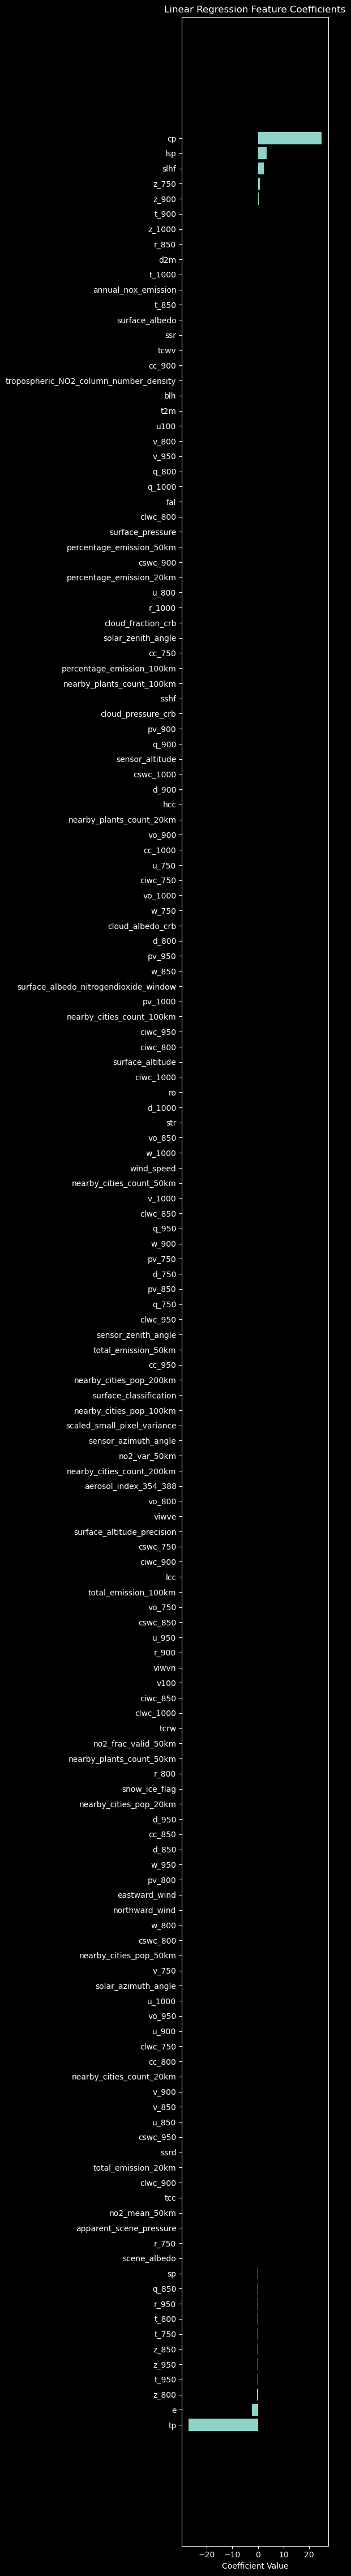

In [84]:
import numpy as np
import matplotlib.pyplot as plt

feature_names = X.columns
coefs = model.coef_  # for LinearRegression this is already 1-d

# sort for better visualization
indices = np.argsort(coefs)

plt.figure(figsize=(6, len(feature_names)*0.3))
plt.barh(feature_names[indices], coefs[indices])
plt.xlabel("Coefficient Value")
plt.title("Linear Regression Feature Coefficients")
plt.tight_layout()
plt.show()

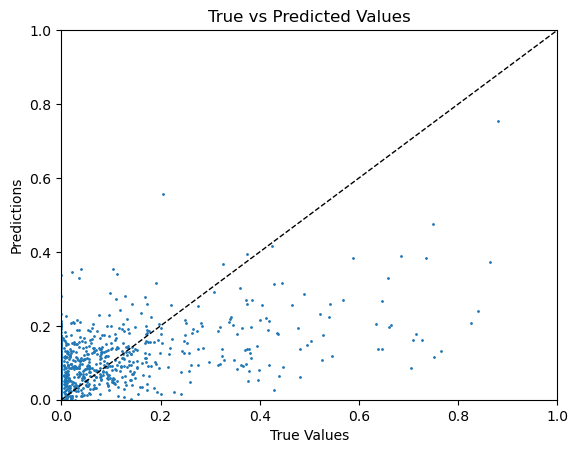

In [85]:
plt.rcdefaults()
plt.scatter(y_test, y_pred,s=1)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)  # identity line
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.title("True vs Predicted Values")
plt.show()

In [7]:
df_means

,location,wind_u,wind_v,plume_label,annual_nox_emission,no2_mean_50km,no2_var_50km,no2_frac_valid_50km,surface_altitude,surface_altitude_precision,...,percentage_emission_100km,nearby_cities_count_20km,nearby_cities_pop_20km,nearby_cities_count_50km,nearby_cities_pop_50km,nearby_cities_count_100km,nearby_cities_pop_100km,nearby_cities_count_200km,nearby_cities_pop_200km,wind_speed
0,CoCO2_00006,3.523047,-2.018198,0.075314,5881.364106,0.000019,4.043600e-11,0.954014,139.042548,76.425969,...,99.952861,2.0,568884.0,4.0,1189611.0,6.0,1445134.0,23.0,4113568.0,4.228074
1,CoCO2_00007,5.398261,0.695366,0.000000,8168.561258,0.000029,1.975637e-10,0.952672,61.973039,21.486558,...,30.558001,5.0,12376210.0,6.0,12598738.0,7.0,12676014.0,12.0,13232705.0,5.667480
2,CoCO2_00008,-1.477974,-0.304918,0.004202,980.227351,0.000023,1.431925e-10,0.950309,1663.411715,34.011208,...,100.000000,1.0,665564.0,1.0,665564.0,7.0,1486208.0,25.0,4414362.0,2.343570
3,CoCO2_00009,-2.096192,-0.459157,0.000000,5227.879205,0.000015,4.909257e-11,0.936223,1842.333097,105.528307,...,100.000000,1.0,776249.0,3.0,1056063.0,3.0,1056063.0,10.0,2052883.0,3.097518
4,CoCO2_00010,5.447026,0.677386,0.000000,6273.455046,0.000030,1.952631e-10,0.952440,35.062604,30.120133,...,23.468545,4.0,11876210.0,7.0,12676014.0,7.0,12676014.0,12.0,13232705.0,5.693483
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,CoCO2_16411,1.318072,1.316161,0.188095,470.000000,0.000076,2.317300e-09,0.850310,33.006605,37.211558,...,3.232677,3.0,311269.0,7.0,824196.0,17.0,2777838.0,48.0,8059738.0,5.098302
5996,CoCO2_16417,0.784641,0.170133,0.079787,434.000000,0.000074,1.228245e-09,0.879173,44.749885,10.536387,...,9.903087,0.0,0.0,7.0,710658.0,21.0,3379722.0,71.0,18581564.0,4.191149
5997,CoCO2_16420,1.642037,0.983188,0.000000,258.000000,0.000065,1.023985e-09,0.867056,13.675498,16.545707,...,5.979032,1.0,707412.0,7.0,1723155.0,18.0,2831285.0,62.0,11964380.0,4.827516
5998,CoCO2_16422,1.119171,1.249138,0.009901,534.202000,0.000034,3.743112e-10,0.862851,15.652485,17.494482,...,19.253890,4.0,1732297.0,4.0,1732297.0,4.0,1732297.0,7.0,2209779.0,4.804617
